# 05 — Sentinel-1 SAR Processing Walkthrough

How the observed flood extent was derived from raw Sentinel-1 GRD scenes: GCP-based georeferencing, per-scene water classification, and before/after differencing. See `../src/10_sentinel1_flood_extent.py` for the production pipeline this notebook mirrors, and `../PROTOCOL.md` for the scene-selection process (including two rounds of mislocated scenes caught and corrected).

In [1]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PROC = Path('../data/processed')
DATA_RAW = Path('../data/raw')

## Raw GRD georeferencing

Sentinel-1 GRD products carry only ground control points (no direct affine transform) — this is why a GCP-based warp is needed before any spatial cropping or analysis.

In [2]:
s1_dir = DATA_RAW / 'flood' / 'sentinel1' / 'extracted'
tiff = next(s1_dir.glob('*6B40*/measurement/*vv*.tiff'))
with rasterio.open(tiff) as src:
    print('shape:', src.shape)
    print('crs:', src.crs, '(None expected -- no direct georeferencing)')
    print('gcp count:', len(src.gcps[0]))
    print('gcp crs:', src.gcps[1])
    print('sample gcp:', src.gcps[0][0])

shape: (16805, 25536)
crs: None (None expected -- no direct georeferencing)
gcp count: 210
gcp crs: EPSG:4326
sample gcp: GroundControlPoint(row=0.0, col=0.0, x=116.6029621897085, y=-2.47221144227837, z=-2.6635825634002686e-07, id='1', info='')


## Baseline vs. event water classification

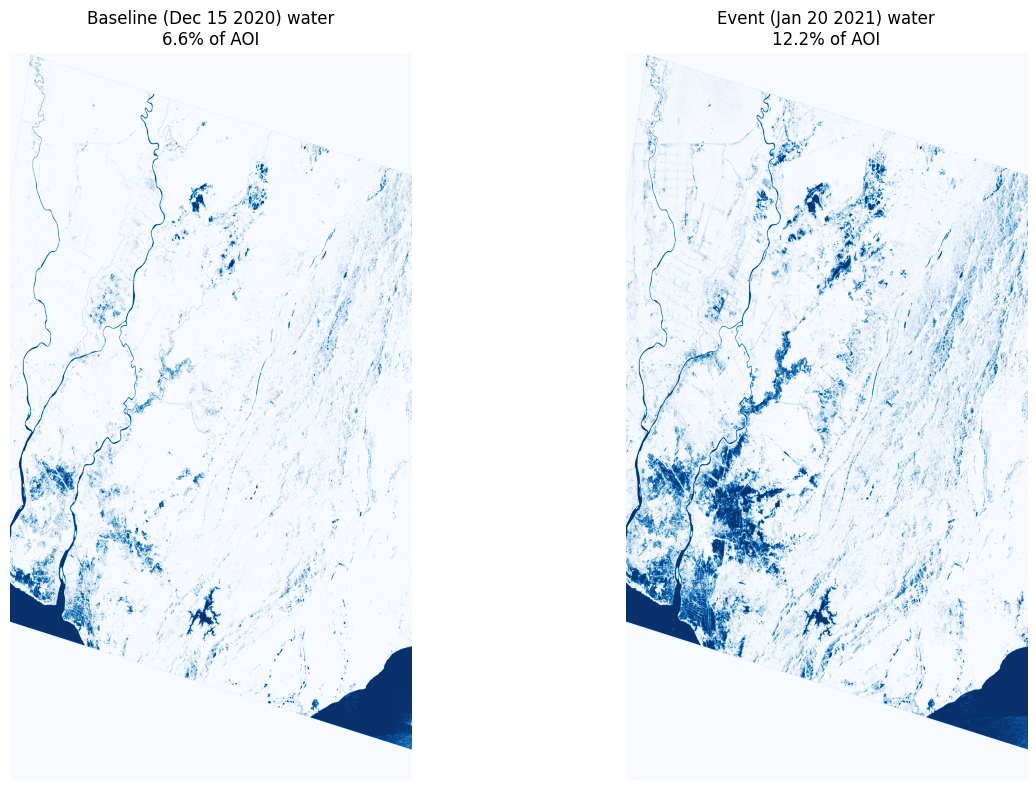

In [3]:
with rasterio.open(DATA_PROC / 's1_baseline_water.tif') as src:
    baseline_water = src.read(1)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
with rasterio.open(DATA_PROC / 's1_event_water.tif') as src:
    event_water = src.read(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].imshow(baseline_water, extent=extent, cmap='Blues')
axes[0].set_title(f'Baseline (Dec 15 2020) water\n{100*baseline_water.mean():.1f}% of AOI')
axes[0].set_axis_off()
axes[1].imshow(event_water, extent=extent, cmap='Blues')
axes[1].set_title(f'Event (Jan 20 2021) water\n{100*event_water.mean():.1f}% of AOI')
axes[1].set_axis_off()
plt.tight_layout()
plt.show()

## New flood extent

Event water minus baseline water — removes permanent rivers and water bodies common to both dates, isolating the actual flood.

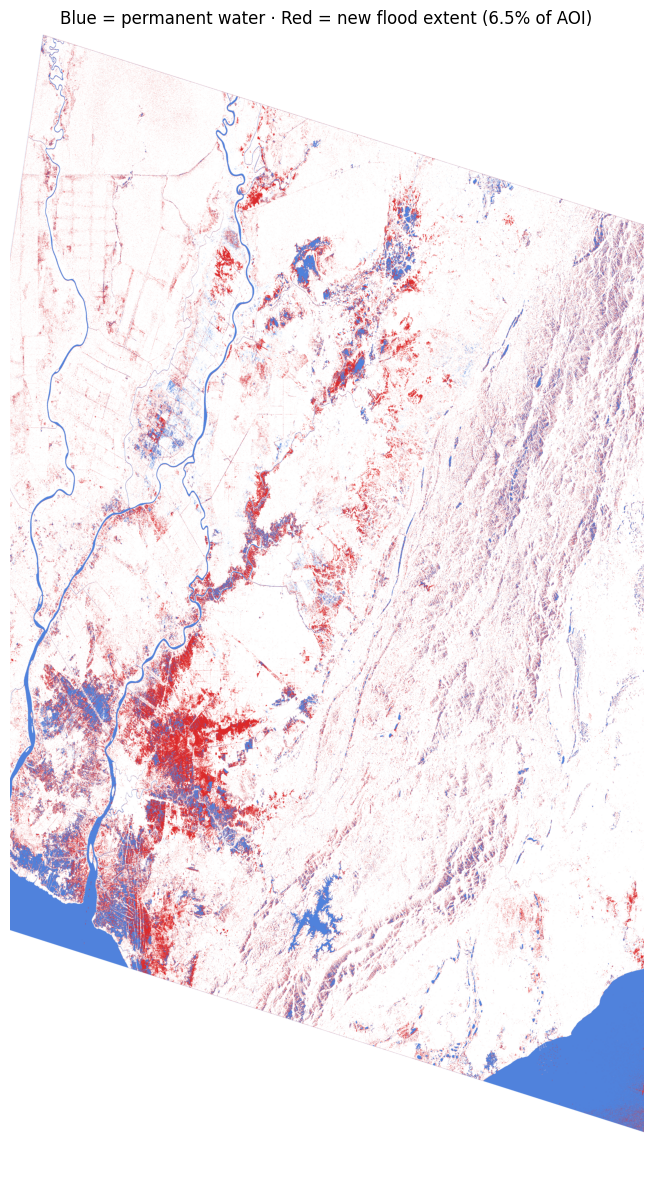

In [4]:
with rasterio.open(DATA_RAW / 'flood' / 'sentinel1_observed_flood_extent.tif') as src:
    new_flood = src.read(1)

h, w = new_flood.shape
rgb = np.full((h, w, 3), 255, dtype='uint8')
rgb[baseline_water == 1] = [80, 130, 220]
rgb[new_flood == 1] = [220, 40, 40]

fig, ax = plt.subplots(figsize=(9, 12))
ax.imshow(rgb, extent=extent)
ax.set_title(f'Blue = permanent water · Red = new flood extent ({100*new_flood.mean():.1f}% of AOI)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

**Visual validation:** flooding concentrates tightly along the Barito river corridor and the low-lying delta near Banjarmasin, while the mountainous Meratus range (east side of the AOI) shows negligible flooded area — the physically expected pattern, and the basis for treating this classification as a genuine flood signal rather than SAR noise.